DECISION TREE

A decision tree is a simple, tree-like model used in decision-making and machine learning, where decisions are made step by step through a series of questions. It starts from a root node, branches out based on conditions, and ends at leaf nodes that give the final outcome. Decision trees are widely used for classification (predicting categories) and regression (predicting values). Their structure closely mimics human thinking, making them easy to understand and useful for visually representing decisions and outcomes.

EXAMPLE:

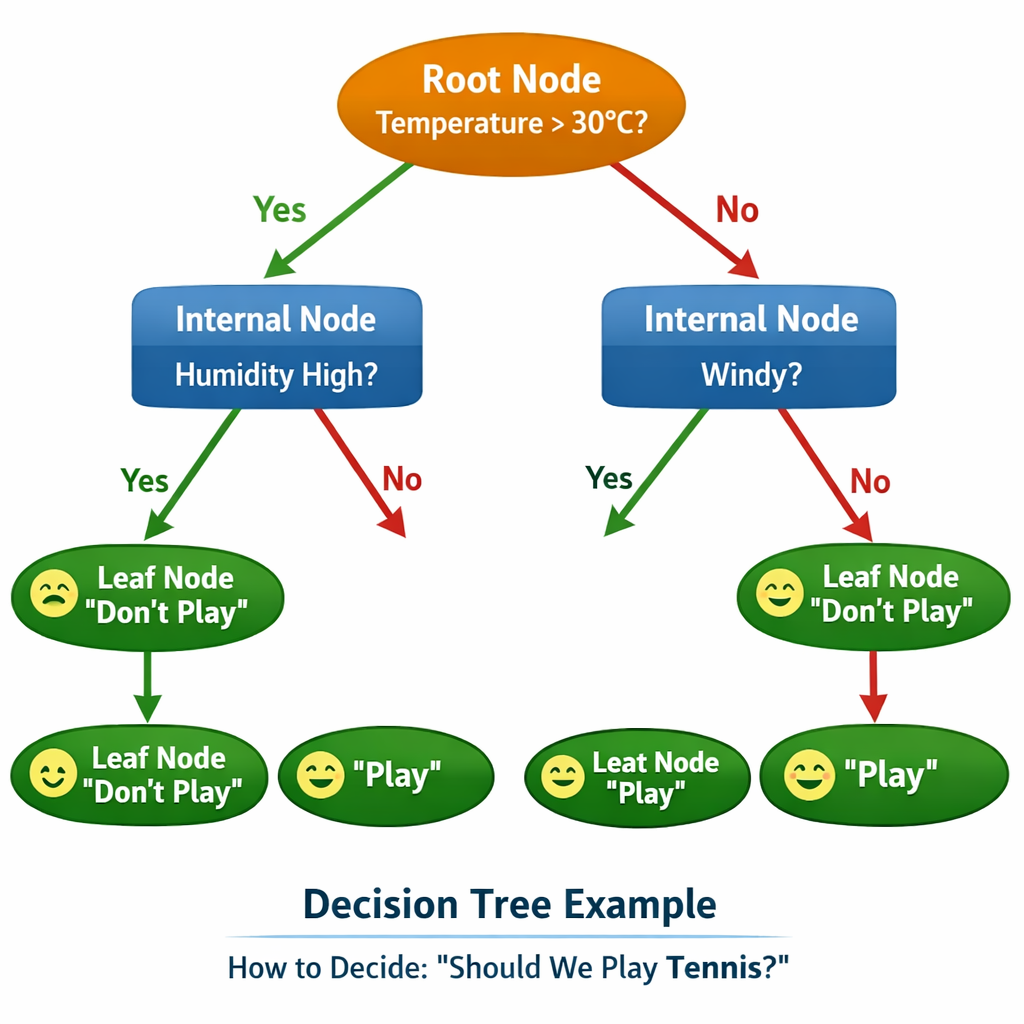

Classification and Regression Trees (CART)

In modern machine learning, the decision tree algorithm is commonly referred to as CART (Classification and Regression Trees). This term was introduced by Leo Breiman to describe decision tree methods that can handle both classification (categorical outcomes) and regression (continuous values) problems. CART serves as a fundamental building block for more advanced ensemble techniques such as bagging, random forests, and boosting methods.

In this project, the focus is on a classification task, so the approach will specifically involve a decision tree classifier.

Key Regularization Parameters

To control the complexity of a decision tree and prevent overfitting, several parameters are used:

1) Max_depth: Determines the maximum number of levels from the root to the deepest leaf. Limiting depth helps avoid overly complex trees that memorize the data instead of generalizing.

2) Min_samples_split: Sets the minimum number of samples required to split an internal node. If the number of samples is too small, further splitting is stopped.

3) Min_samples_leaf: Specifies the minimum number of samples that must be present in a leaf node. This helps ensure that leaf nodes are not too small, reducing the risk of overfitting.

4) Max_leaf_nodes: Limits the total number of leaf nodes in the tree, helping to control model size and complexity.

5) Max_features: Defines the number of features considered when determining the best split at each node, which can improve model performance and efficiency.

6) Min_weight_fraction_leaf: Similar to minimum samples per leaf, but expressed as a fraction of the total weighted samples.



Libraries and Tools Used

The following libraries are used to build and evaluate the model:

1) NumPy and Pandas: For numerical computations and handling structured data
2) Matplotlib and Seaborn: For data visualization, including plots and performance graphs
3) train_test_split: To divide the dataset into training and testing sets
4) load_wine: To import a sample dataset from scikit-learn
5) accuracy_score and other metrics: For evaluating model performance (e.g., accuracy, confusion matrix)
6) StandardScaler: For scaling features to improve model performance

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv('/content/advertising.csv')

<Figure size 1000x1000 with 0 Axes>

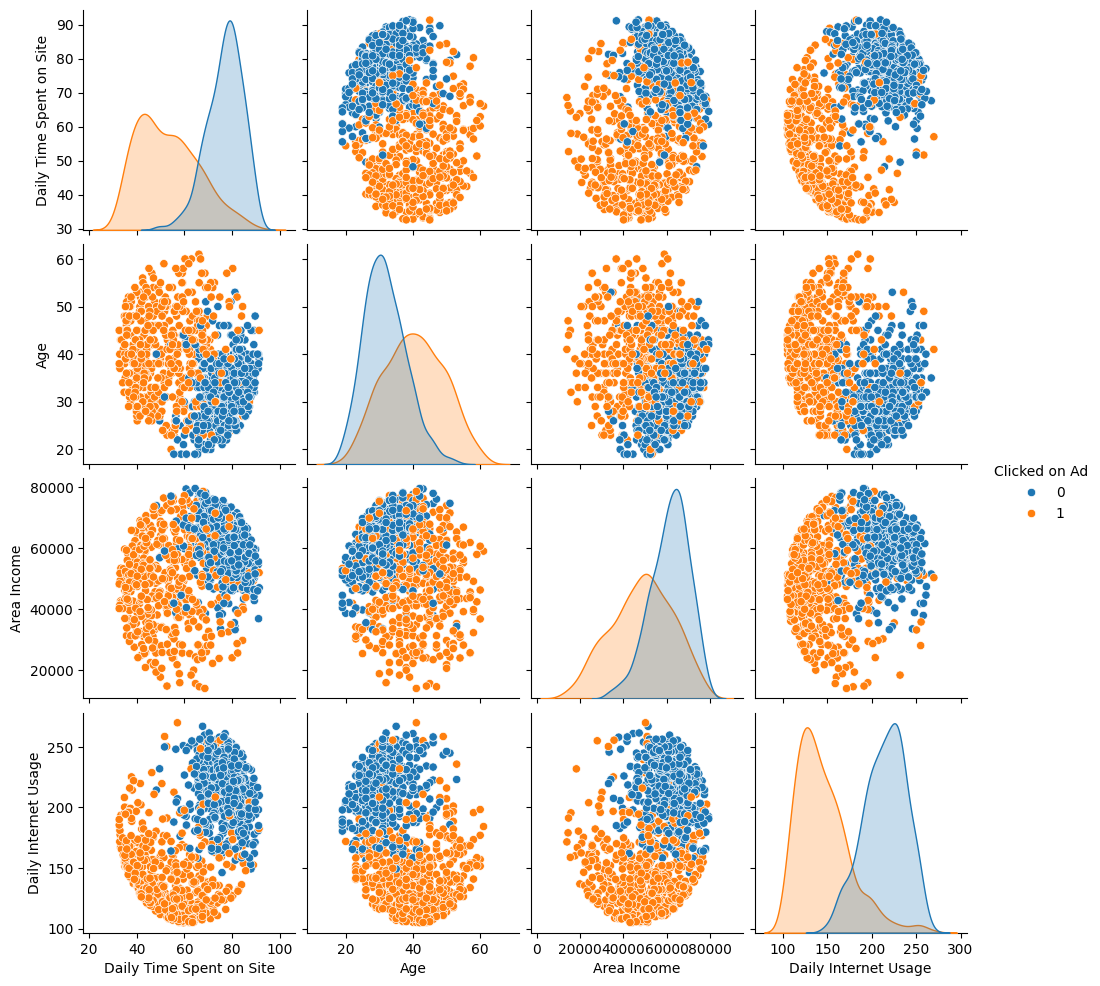

In [11]:
plt.figure(figsize=(10, 10))
sns.pairplot(
    data,
    hue ='Clicked on Ad',
    vars=['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage'],
    diag_kind='kde',
)
plt.show()

In [12]:
X = data[['Age','Daily Time Spent on Site']]
y = data['Clicked on Ad']

In [13]:
X= X.to_numpy()
y = y.to_numpy ()

In [14]:
colors = ['blue' if label == 0 else 'orange' for label in y]

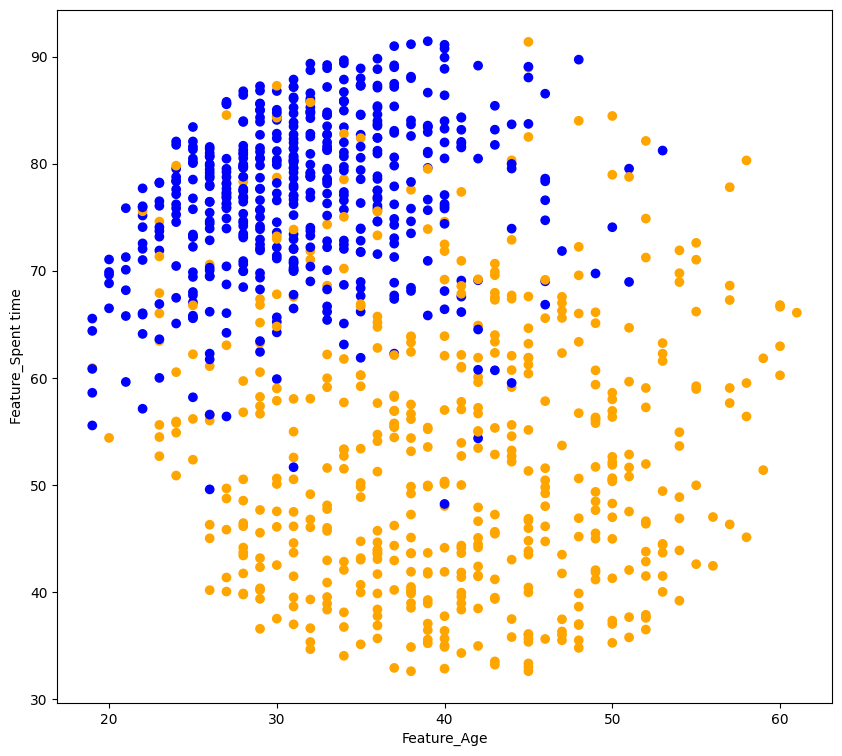

In [15]:
plt.figure (figsize=(10,9))
plt.scatter (X[:,0], X[:,1], c= colors)
plt.xlabel ('Feature_Age')
plt.ylabel ('Feature_Spent time')
plt.show ()

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size= 0.4, random_state =42)

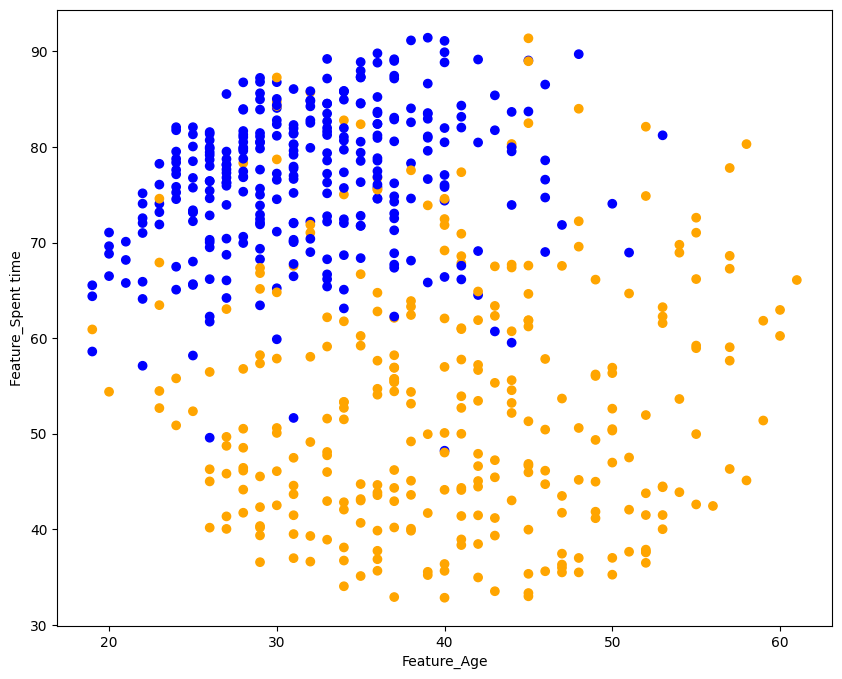

In [17]:
c_train = ['blue' if label == 0 else 'orange' for label in y_train]
c_test = ['blue' if label == 0 else 'orange' for label in y_test]
plt.figure (figsize =(10,8))

plt.scatter (X_train[:,0], X_train [:,1], c= c_train)
plt.xlabel ('Feature_Age')
plt.ylabel ('Feature_Spent time')
plt.show ()

In [18]:
features = ['X_0','X_1']
labels = ['blue','orange']

In this section, a Decision Tree classifier is developed and assessed to predict whether a user will click on an advertisement. The model is trained using selected features from the dataset, allowing it to learn decision rules that distinguish between different outcomes. To prevent overfitting and maintain simplicity, the tree depth is limited to three levels using a max depth constraint, while a fixed random state is applied to ensure consistent and reproducible results. The model is then trained on the provided training data, where it identifies patterns and relationships that help in class separation.

After training, the model is applied to unseen test data to generate predictions. Its performance is evaluated using standard classification metrics. Precision measures how many of the predicted positive cases are actually correct, while recall indicates how effectively the model identifies all actual positive cases. The F1-score provides a balanced measure by combining precision and recall into a single value. Additionally, support reflects the number of instances present in each class, giving context to the evaluation results.

Moudles used:
1) DecisionTreeClassifier from sklearn.tree
2) metrics from sklearn

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [29]:
decision_tree = DecisionTreeClassifier(max_depth =3, random_state =42)
decision_tree.fit (X_train, y_train)
DecisionTreeClassifier(max_depth=3, random_state=42)
print ('decision_tree')
print (metrics.classification_report (y_test, decision_tree.predict (X_test)))

decision_tree
              precision    recall  f1-score   support

           0       0.81      0.97      0.88       191
           1       0.97      0.78      0.87       209

    accuracy                           0.88       400
   macro avg       0.89      0.88      0.87       400
weighted avg       0.89      0.88      0.87       400



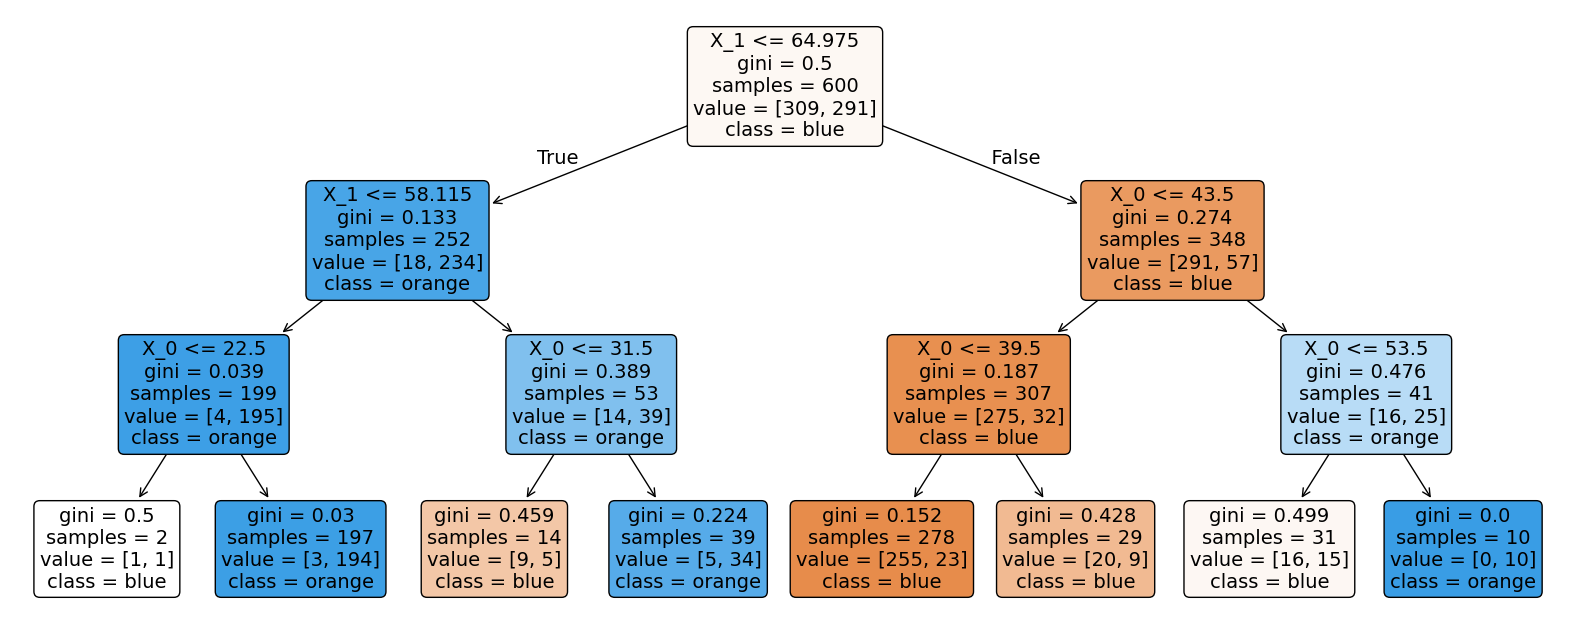

In [30]:
from sklearn import tree

plt.figure (figsize =(20,8))
a = tree.plot_tree (decision_tree,
              feature_names = features,
              class_names = labels,
              rounded = True,
              filled = True,
              fontsize =14)
plt.show ()

In [31]:
from sklearn.tree import export_text

tree_rules = export_text (decision_tree, feature_names =features)
print (tree_rules)

|--- X_1 <= 64.97
|   |--- X_1 <= 58.11
|   |   |--- X_0 <= 22.50
|   |   |   |--- class: 0
|   |   |--- X_0 >  22.50
|   |   |   |--- class: 1
|   |--- X_1 >  58.11
|   |   |--- X_0 <= 31.50
|   |   |   |--- class: 0
|   |   |--- X_0 >  31.50
|   |   |   |--- class: 1
|--- X_1 >  64.97
|   |--- X_0 <= 43.50
|   |   |--- X_0 <= 39.50
|   |   |   |--- class: 0
|   |   |--- X_0 >  39.50
|   |   |   |--- class: 0
|   |--- X_0 >  43.50
|   |   |--- X_0 <= 53.50
|   |   |   |--- class: 0
|   |   |--- X_0 >  53.50
|   |   |   |--- class: 1



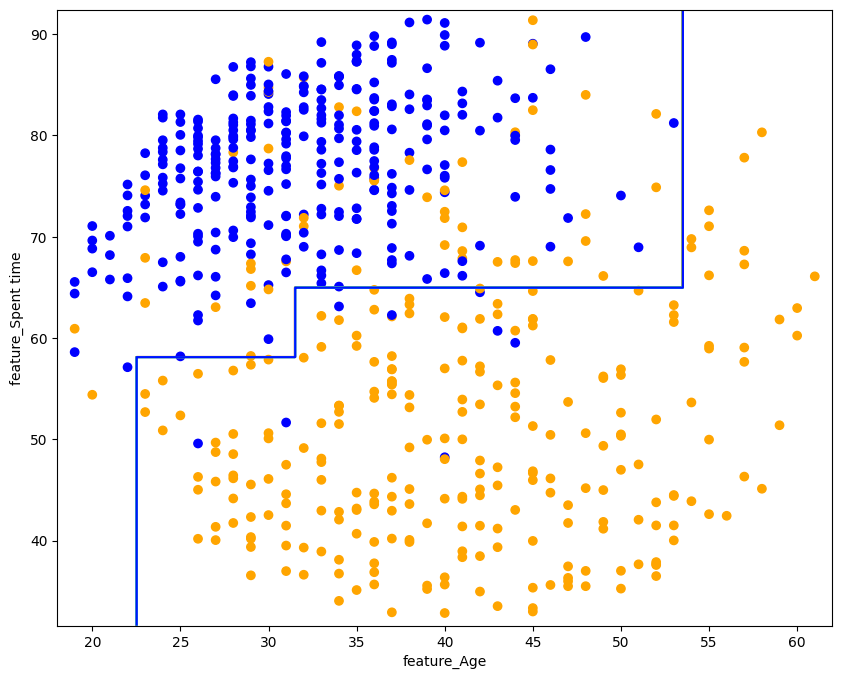

In [32]:
# Set a plot_step
plot_step =0.02

plt.figure (figsize=(10,8))
# plot the decision boundary
x_min, x_max = X [:,0].min ()-1, X[:,0].max()+1
y_min, y_max = X [:,1].min ()-1, X[:,1].max()+1

# plt.tight_layout
xx, yy = np.meshgrid (np.arange (x_min, x_max, plot_step),
                     np.arange (y_min, y_max, plot_step))

Z = decision_tree.predict (np.c_[xx.ravel (), yy.ravel ()])
Z = Z.reshape (xx.shape)
cs = plt.contour (xx, yy, Z, cmap ='jet_r')

plt.scatter (X_train [:,0], X_train [:,1], c = c_train)
plt.xlabel ('feature_Age')
plt.ylabel ('feature_Spent time')
plt.show ()


Once predictions are obtained from the trained Decision Tree model, its performance is assessed using a confusion matrix. The function metrics.confusion_matrix(y_test, y_pred) is used to calculate the number of correct and incorrect classifications made by the model on the test dataset. The resulting matrix is then transformed into a Pandas DataFrame (matrix_dt), which allows for easier handling and visualization.

In [33]:
y_pred = decision_tree.predict (X_test)

# import metrics from sklearn
from sklearn import metrics
import seaborn as sns

# The confusion matrix
confusion_matrix = metrics.confusion_matrix (y_test, y_pred)

# Convert confusion matrix into dataframe
matrix_dt = pd.DataFrame (confusion_matrix)

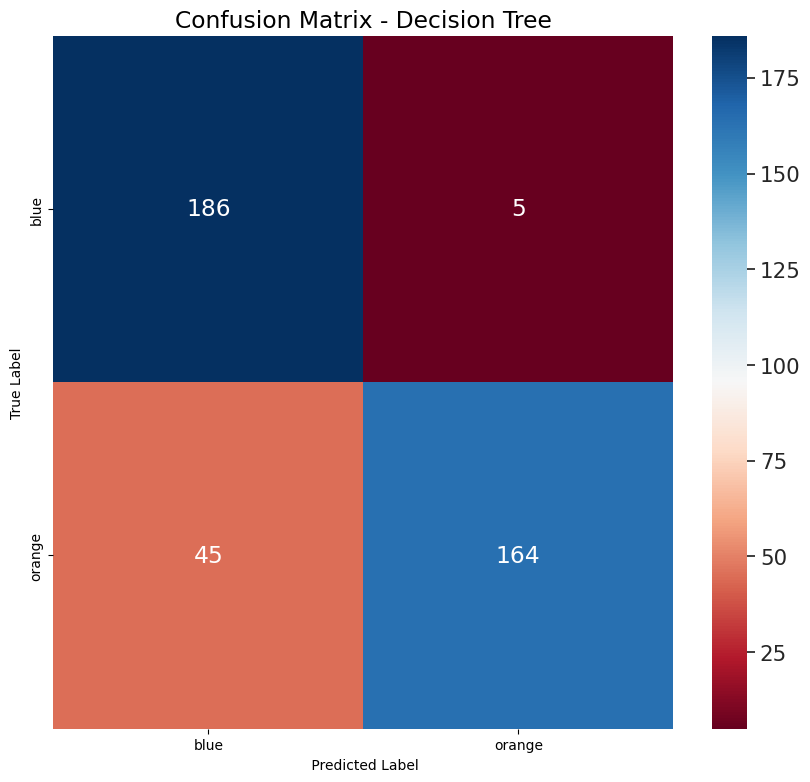

In [34]:
plt.figure (figsize =(10,9))

ax= plt.axes ()
sns.set (font_scale =1.4)
sns.heatmap(matrix_dt,
            annot =True,
           fmt = 'g',
           ax = ax,
          cmap="RdBu")

ax.set_title ('Confusion Matrix - Decision Tree')
ax.set_xlabel (' Predicted Label', fontsize =10)
ax.set_xticklabels (labels)
ax.set_ylabel ('True Label', fontsize =10)
ax.set_yticklabels (labels)
plt.show ()

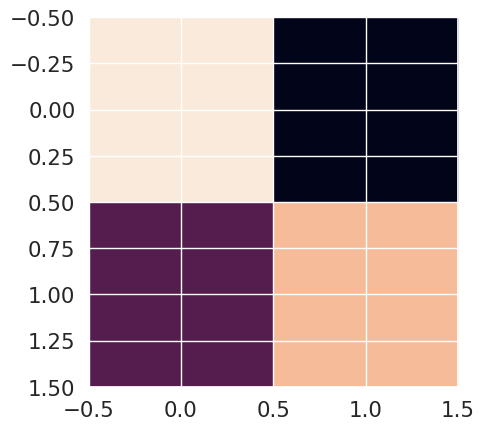

In [35]:
plt.imshow (confusion_matrix)

In [36]:
print (f'accuracy score = { metrics.accuracy_score (y_test, y_pred)}')

accuracy score = 0.875


In [37]:
print (f'precision score')
precision = metrics.precision_score (y_test,
                                     y_pred,
                                    average = None)

precision_results = pd.DataFrame (precision, index = labels)
precision_results.rename (columns= {0:'precison'}, inplace = True)
precision_results

precision score


,precison
blue,0.805195
orange,0.970414


In [38]:
print (metrics.classification_report (y_test,
                                     y_pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.88       191
           1       0.97      0.78      0.87       209

    accuracy                           0.88       400
   macro avg       0.89      0.88      0.87       400
weighted avg       0.89      0.88      0.87       400



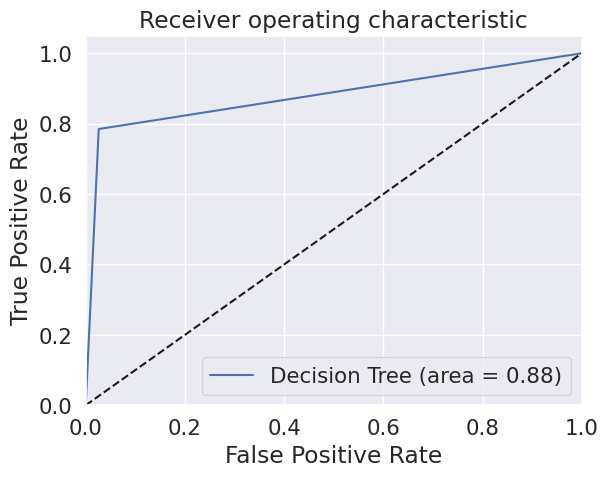

In [39]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
dt_roc_auc = roc_auc_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr, label='Decision Tree (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1],'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('DT_ROC')
plt.show()


Final Conclusion

The Decision Tree classifier successfully captured the underlying relationships between the input features-Age and Daily Time Spent on Site and the binary target variable representing advertisement click behavior. By constraining the model complexity through a limited tree depth, overfitting was mitigated while preserving the model’s ability to learn meaningful, non-linear decision boundaries and feature-based splits.

Quantitative evaluation using performance metrics such as accuracy, precision, recall, and F1-score indicates that the model achieves consistent and reliable classification across both classes. The confusion matrix further supports this observation by demonstrating balanced prediction outcomes with minimal bias toward either class.

Additionally, analysis of the ROC curve reveals strong discriminative capability, with a favorable AUC value that confirms the model’s effectiveness in distinguishing between positive and negative instances beyond random baseline performance. Overall, the Decision Tree provides a robust, interpretable, and computationally efficient solution for this binary classification problem in online advertisement click prediction.